In [5]:
from ucimlrepo import fetch_ucirepo 
  
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('ggplot')


# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets 
  
df = pd.concat([X, y], axis= 1)


In [6]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 133.5 KB


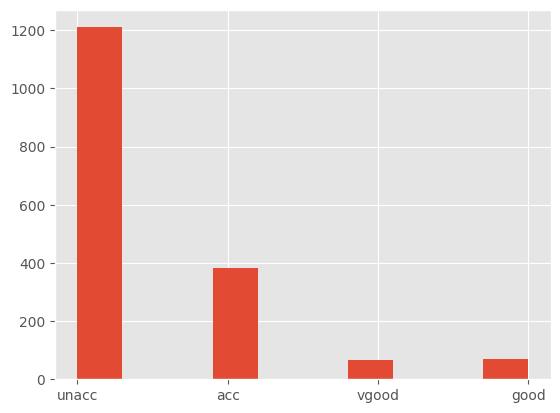

In [8]:
df['class'].hist()
plt.show()

In [12]:
df['target'] = (df['class'] != 'unacc').astype(int)

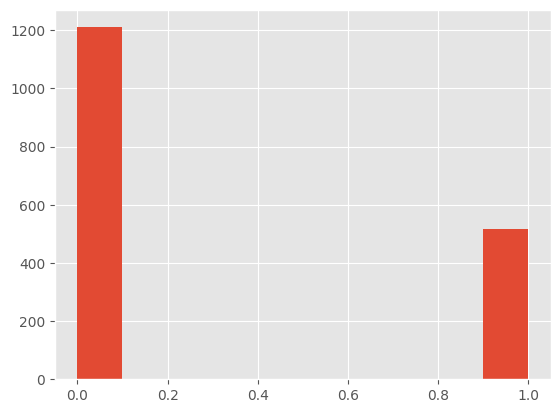

In [14]:
df['target'].hist()
plt.show()

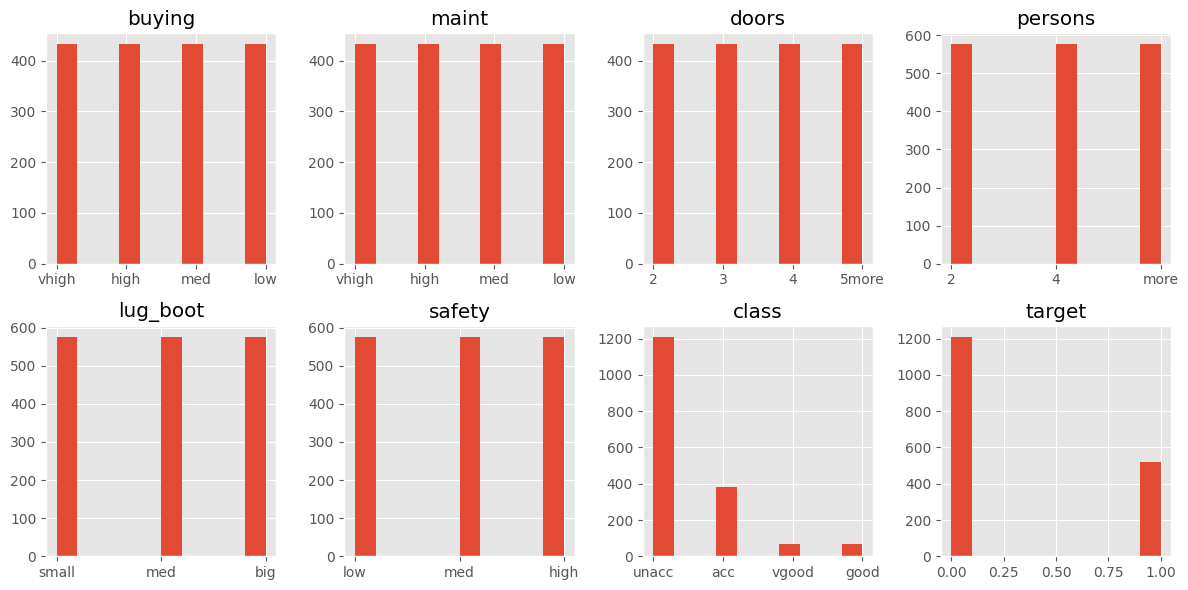

In [19]:
feature = df.columns

plt.figure(figsize= (12, 6))
for count, feat in enumerate(feature):
    plt.subplot(2, 4, count + 1)
    df[feat].hist()
    plt.title(feat)

plt.tight_layout()
plt.show()

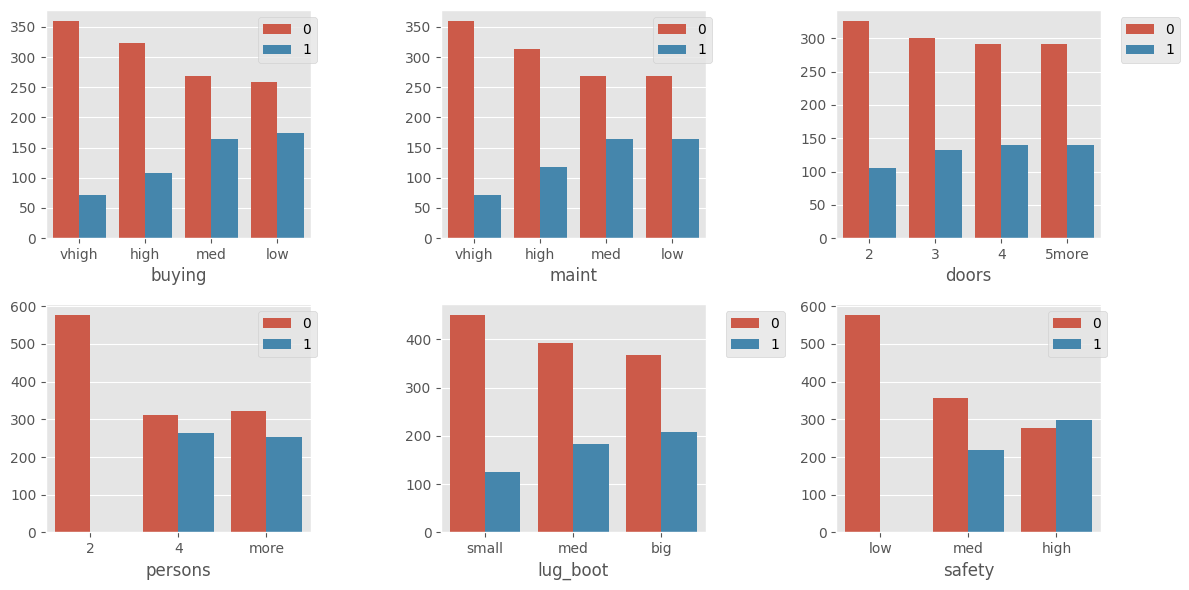

In [27]:
import seaborn as sns

feat_corr = [d for d in df.columns if d not in ['class', 'target']]

plt.figure(figsize= (12, 6))
for count, feat in enumerate(feat_corr):
    plt.subplot(2, 3, count + 1)
    sns.countplot(df, x = feat, hue = 'target')
    plt.legend(bbox_to_anchor = (1.05, 1))
    plt.ylabel('')


plt.tight_layout()
plt.show()

In [28]:
from sklearn.model_selection import train_test_split

cat_features = ['buying', 'maint', 'doors', 'persons', 'lug_boot']

X = df[cat_features].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 8, stratify= y)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()

ratio = neg / pos

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier



preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

models = {
    'base' : Pipeline([
        ('preprocess', preprocessor),
        ('model', LogisticRegression(
            max_iter = 500,
            class_weight= 'balanced'
        ))
    ]),

    'gradient' : Pipeline([
        ('preprocess', preprocessor),
        ('model', GradientBoostingClassifier(
            random_state= 8
        ))
    ]),

    'xgb' : Pipeline([
        ('preprocess', preprocessor),
        ('model', XGBClassifier(
            objective = 'binary:logistic',
            n_estimators = 200,
            random_state = 8,
            scale_pos_weight = ratio
        ))
    ])
}

In [32]:
preds = {}

for name, model in models.items():
    print(f'Training {name}')
    model.fit(X_train, y_train)

    preds[name] = y_pred = model.predict(X_test)

Training base
Training gradient
Training xgb


Report for base
              precision    recall  f1-score   support

           0       0.95      0.73      0.83       242
           1       0.59      0.90      0.71       104

    accuracy                           0.78       346
   macro avg       0.77      0.82      0.77       346
weighted avg       0.84      0.78      0.79       346

Report for gradient
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       242
           1       0.64      0.75      0.69       104

    accuracy                           0.80       346
   macro avg       0.76      0.79      0.77       346
weighted avg       0.81      0.80      0.80       346

Report for xgb
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       242
           1       0.54      0.72      0.62       104

    accuracy                           0.73       346
   macro avg       0.70      0.73      0.71       346
weighted avg       0.76

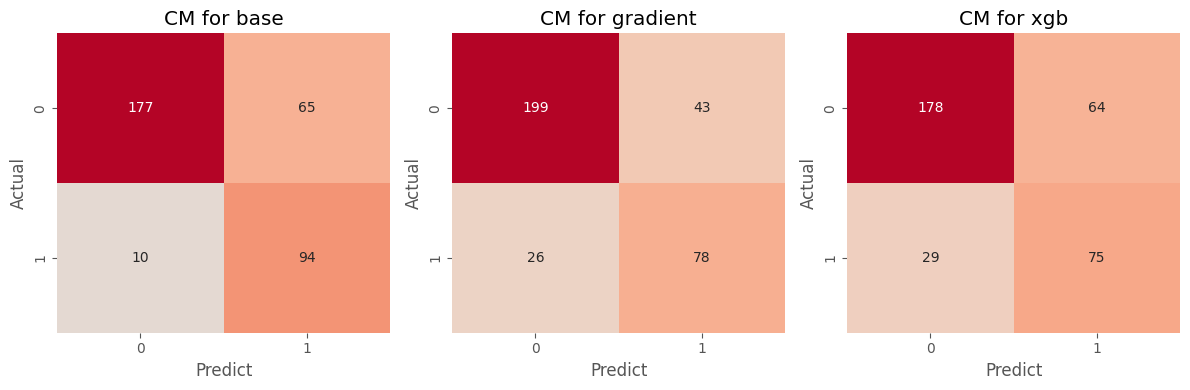

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(12, 4))

for count, (name, y_pred) in enumerate(preds.items()):
    print(f'Report for {name}')
    print(classification_report(y_true= y_test, y_pred= y_pred))

    cm = confusion_matrix(y_true= y_test, y_pred= y_pred)

    plt.subplot(1, 3, count + 1)

    sns.heatmap(cm, cbar = False, cmap = 'coolwarm', center = 0,
                annot = True, fmt = 'd')
    
    plt.ylabel('Actual')
    plt.xlabel('Predict')
    plt.title(f'CM for {name}')

plt.tight_layout()
plt.show()